---

## [실습] ETF 추천 시스템 개선

### 필수 과제
1. **에러 처리 개선**: execute_query 함수에 더 상세한 에러 처리 로직 추가
2. **테스트 검증**: 추천 결과의 필수 필드 검증 로직 추가

### 선택 과제
1. **랭킹 알고리즘 개선**: 사용자 프로필에 따른 가중치 조정 로직 추가
2. **추가 필터링**: 총보수, 순자산총액 임계값 기반 필터링 추가
3. **프롬프트 개선**: Text2SQL 프롬프트의 정확도 향상
4. **프로세스 체인 추가**: 새로운 분석 단계 추가 (예: 포트폴리오 다각화 분석)

### execute_query 에러 처리 개선 

- 텍스트 정제 및 문법 오류 처리 추가

```python 
def execute_query(state: State) -> dict:
    """SQL 쿼리 실행하여 후보 ETF 검색"""
    # 1. 쿼리 원본 가져오기
    raw_query = state.get("query", "")
    # 2. LLM이 마크다운(```sql ... ```)으로 묶어서 줬을 경우를 대비해 텍스트 정제
    clean_query = raw_query.replace("```sql", "").replace("```", "").strip()
    # 디버깅용 쿼리 출력 (어떤 쿼리가 실행되는지 눈으로 확인)
    print(f"========== [실행할 SQL 쿼리] ==========\n{clean_query}\n========================================")
    try:
        execute_query_tool = QuerySQLDatabaseTool(db=db)
        # 정제된 쿼리를 실행
        results = execute_query_tool.invoke(clean_query)
        if not results or results == "[]":
            return {"candidates": "검색 결과가 없습니다. (쿼리 조건에 맞는 데이터가 DB에 존재하지 않습니다.)"}
        return {"candidates": results}
    except sqlalchemy.exc.ProgrammingError as e:
        # SQL 문법 오류나 테이블/컬럼이 존재하지 않을 때 발생하는 구체적인 에러
        error_msg = f"SQL 문법 오류 또는 존재하지 않는 컬럼/테이블 참조: {str(e)}"
        print(f"❌ [에러] {error_msg}")
        return {"candidates": error_msg}
    except Exception as e:
        # 그 외 일반적인 에러
        error_msg = f"쿼리 실행 중 알 수 없는 오류 발생: {str(e)}"
        print(f"❌ [에러] {error_msg}")
        return {"candidates": error_msg}
``` 

### 테스트 검증 

- Pydantic BaseModel 로 변경하여 처리 
```python
from pydantic import BaseModel, Field, field_validator
from typing import List
# ETF Ranking Output (Pydantic 모델로 변경)
class ETFRanking(BaseModel):
    """Individual ETF ranking result"""
    rank: int = Field(..., description="Ranking position (1-5)", ge=1, le=5) # 1~5 제한
    etf_code: str = Field(..., description="ETF 종목코드 (6-digit)", min_length=6, max_length=6)
    etf_name: str = Field(..., description="ETF 종목명")
    score: float = Field(..., description="Composite score (0-100)", ge=0, le=100) # 0~100 제한
    ranking_reason: str = Field(..., description="Explanation for the ranking (in 한국어)")
class ETFRankingResult(BaseModel):
    """Ranked ETFs"""
    rankings: List[ETFRanking] = Field(..., description="List of ranked ETFs")
    
    # 랭킹 결과가 비어있는지 검증
    @field_validator('rankings')
    @classmethod
    def check_rankings_not_empty(cls, v):
        if not v or len(v) == 0:
            raise ValueError("최소 1개 이상의 ETF 랭킹이 생성되어야 합니다.")
        return v

```


## 선택 과제 

### 1.  랭킹 알고리즘 개선
1. Few-Shot Prompting 도입: 기존 QUERY_TEMPLATE에 사용자가 자주 할 법한 질문과 예상되는 올바른 SQL 쿼리 예시(Few-Shot)를 2~3개 정도 추가

2. 스키마 설명 구체화: 테이블 정보(table_info) 외에, "AUM 단위는 원이다. ", "총보수는 소수점 단위이다" 같은 컬럼 메타데이터 설명을 프롬프트에 추가

3. 안전장치 추가: "존재하지 않는 테이블은 절대 조회하지 마시오", "ORDER BY 시 반드시 존재하는 컬럼만 사용하시오" 등의 제약 조건을 강화합니다.

### 2. 추가 필터링 (총보수, 순자산총액 임계값)

정확해진 쿼리로 데이터를 가져올 때, 애초에 투자 가치가 떨어지는(규모가 너무 작거나 수수료가 비싼) ETF를 쳐내는 작업을 합니다.

SYSTEM_TEMPLATE의 ## Constraints (제약조건) 추가

### 3. 랭킹 알고리즘 개선 (사용자 성향 기반 가중치)

필터링까지 통과한 알짜 후보군들을 대상으로, 사용자의 '투자 성향'에 맞게 점수를 차등 부여합니다.

- 가중치 매트릭스 프롬프트 추가: ranking_prompt에 명시적인 채점 기준을 부여합니다.
예: "사용자가 '위험회피형'이라면 변동성이 낮은 종목에 가중치 +30점, '공격투자형'이라면 최근 수익률이 높은 종목에 가중치 +30점을 부여하여 score를 계산하라."
- 정량 + 정성 평가 분리: 단순 LLM의 '감'에 의존하지 않고, LLM에게 "먼저 수익률, 보수 등을 기반으로 정량 점수(70점 만점)를 매기고, 사용자의 투자 목적 부합도를 정성 점수(30점 만점)로 매겨 합산하라"고 명확히 지시합니다.

### 4. 프로세스 체인 추가 (포트폴리오 다각화 분석)

최종적으로 랭킹이 매겨진 Top 5 ETF를 그냥 보여주는 것에서 끝나지 않고, "이 5개를 같이 샀을 때 위험하지 않은지(섹터 쏠림 등)" 분석하는 단계를 추가합니다.

- State 구조 업데이트: TypedDict State에 diversification_report: str 필드를 하나 새로 추가합니다.

- 새로운 노드 생성: analyze_diversification(state) 함수를 만듭니다. 이 함수는 Top 5로 꼽힌 ETF들의 '섹터'나 '테마'를 확인하고, 너무 특정 산업(예: 반도체)에만 몰려있지 않은지 분석합니다.

- LLM 평가: 새로운 프롬프트를 만들어 LLM에게 최종 5개 목록을 던져주며 "이 포트폴리오의 분산 투자 관점에서의 장단점을 3줄로 요약해"라고 지시합니다.
그래프(Graph) 연결: rank_etfs 노드 ➡️ analyze_diversification 노드 ➡️ generate_explanation 노드 순으로 엣지(Edge)를 이어줍니다.

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import warnings
warnings.filterwarnings('ignore')

In [3]:
from langchain_community.utilities import SQLDatabase

# ETF 데이터베이스 연결
db = SQLDatabase.from_uri(
    "sqlite:///etf_database.db",
    ignore_tables=['ETFsInfo']
    )

# 사용 가능한 테이블 목록 
print(db.dialect)
print(db.get_usable_table_names())
etfs = db.run("SELECT * FROM ETFs LIMIT 5;")

for etf in eval(etfs):
    print(etf)

sqlite
['ETFs']
('466400', '1Q 25-08 회사채(A+이상)액티브', '2023/09/19', '채권-회사채-단기', '하나자산운용', 4.52, 'KIS 2025-08만기형 크레딧 A+이상 지수(총수익)', 0.11, 111916276404.0, 0.03, '매우낮음', '실물(액티브)', 0.1, '배당소득세(보유기간과세)')
('491610', '1Q CD금리액티브(합성)', '2024/09/24', '기타', '하나자산운용', 0.0, 'KIS 하나 CD금리 총수익지수', 0.05, 316206006696.0, 0.02, '매우낮음', '합성(액티브)', 0.02, '배당소득세(보유기간과세)')
('451060', '1Q K200액티브', '2023/01/31', '주식-시장대표', '하나자산운용', -3.66, '코스피 200', 0.77, 99754348820.0, -0.01, '높음', '실물(액티브)', 0.18, '배당소득세(보유기간과세)')
('463290', '1Q 단기금융채액티브', '2023/08/03', '채권-혼합-단기', '하나자산운용', 4.01, 'MK 머니마켓 지수(총수익)', 0.05, 252717462257.0, 0.0, '매우낮음', '실물(액티브)', 0.08, '배당소득세(보유기간과세)')
('479080', '1Q 머니마켓액티브', '2024/04/02', '채권-혼합-단기', '하나자산운용', 0.0, 'KIS-하나 MMF 지수(총수익)', 0.06, 308255065986.0, -0.01, '매우낮음', '실물(액티브)', 0.05, '배당소득세(보유기간과세)')


In [4]:
pprint(db.run("select count(*) from ETFs"))

metadata_text = db.get_table_info()
print(metadata_text)

'[(930,)]'

CREATE TABLE "ETFs" (
	"종목코드" TEXT, 
	"종목명" TEXT, 
	"상장일" TEXT, 
	"분류체계" TEXT, 
	"운용사" TEXT, 
	"수익률_최근1년" REAL, 
	"기초지수" TEXT, 
	"추적오차" REAL, 
	"순자산총액" REAL, 
	"괴리율" REAL, 
	"변동성" TEXT, 
	"복제방법" TEXT, 
	"총보수" REAL, 
	"과세유형" TEXT, 
	PRIMARY KEY ("종목코드")
)

/*
3 rows from ETFs table:
종목코드	종목명	상장일	분류체계	운용사	수익률_최근1년	기초지수	추적오차	순자산총액	괴리율	변동성	복제방법	총보수	과세유형
466400	1Q 25-08 회사채(A+이상)액티브	2023/09/19	채권-회사채-단기	하나자산운용	4.52	KIS 2025-08만기형 크레딧 A+이상 지수(총수익)	0.11	111916276404.0	0.03	매우낮음	실물(액티브)	0.1	배당소득세(보유기간과세)
491610	1Q CD금리액티브(합성)	2024/09/24	기타	하나자산운용	0.0	KIS 하나 CD금리 총수익지수	0.05	316206006696.0	0.02	매우낮음	합성(액티브)	0.02	배당소득세(보유기간과세)
451060	1Q K200액티브	2023/01/31	주식-시장대표	하나자산운용	-3.66	코스피 200	0.77	99754348820.0	-0.01	높음	실물(액티브)	0.18	배당소득세(보유기간과세)
*/


## 고유명사 추출

In [5]:
import ast
import re

def query_as_list(db, query):
    res = db.run(query)
    res = [el for sub in ast.literal_eval(res) for el in sub if el]
    res = [re.sub(r"\b\d+\b", "", string).strip() for string in res]
    return list(set(res))


etfs = query_as_list(db, "SELECT DISTINCT 종목명 FROM ETFs")
fund_managers = query_as_list(db, "SELECT DISTINCT 운용사 FROM ETFs")
underlying_assets = query_as_list(db, "SELECT DISTINCT 기초지수 FROM ETFs")

print("ETFs:", len(etfs))
print("Fund Managers:", len(fund_managers))
print("Underlying Assets:", len(underlying_assets))

print(etfs[:5])
print(fund_managers[:5])
print(underlying_assets[:5])

ETFs: 925
Fund Managers: 26
Underlying Assets: 665
['KODEX 코스피100', 'TIGER 글로벌자원생산기업(합성 H)', 'TIGER 국고채30년스트립액티브', 'KODEX 미국스마트모빌리티S&P', 'TIGER 미국나스닥100']
['대신자산운용', '삼성자산운용', '유리에셋', '미래에셋자산운용', '케이씨지아이자산운용']
['iSelect 2차전지양극재 지수', 'FnGuide 수소 경제 테마 지수', 'S&P GSCI Industrial Metals Select Index(TR)', 'MSCI Korea ESG Universal Capped Index', 'MSCI World IMI Virology Select Index']


### 고유명사를 벡터스토어에 저장

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

# 임베딩 모델 생성
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

# 임베딩 벡터 저장소 생성
vector_store = InMemoryVectorStore(embeddings)

# ETF 종목명과 운용사를 임베딩 벡터로 변환
_ = vector_store.add_texts(etfs + fund_managers + underlying_assets)
vector_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

In [7]:
from typing import Optional, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 1. LLM이 출력할 구조 정의
class SearchQueryAnalyzer(BaseModel):
    query: str = Field(
        description="벡터 검색에 사용할 핵심 검색어 또는 고유명사 (예: '삼성', '다우존스', '미래에셋')"
    )
    filter_type: Optional[Literal["종목명", "운용사", "기초지수"]] = Field(
        default=None,
        description="사용자 질문에서 특정 타입의 대상을 검색하고자 하는 의도가 명확할 때만 지정합니다. (예: '삼성 운용사' -> '운용사', '코스피 지수 관련' -> '기초지수')"
    )

# 2. 구조화된 출력을 지원하는 LLM 선언
llm = ChatOpenAI(model="gpt-4.1", temperature=0)
structured_analyzer = llm.with_structured_output(SearchQueryAnalyzer)

In [8]:
# 3. 자연어 질문 분석 및 동적 필터 적용 검색 함수 정의
def search_vector_store(user_question: str):
    # LLM을 통해 질문 분석
    analysis: SearchQueryAnalyzer = structured_analyzer.invoke(user_question)
    print(f"질문 분석 결과: 쿼리='{analysis.query}', 필터='{analysis.filter_type}'")
    
    # 동적 필터 딕셔너리 생성
    # InMemoryVectorStore에 맞는 동적 필터 구현 예시
    if analysis.filter_type:
        # 각 Document의 metadata['type']과 추출된 filter_type을 동적으로 비교하는 람다 함수 전달
        search_filter = lambda doc: doc.metadata.get("type") == analysis.filter_type
    else:
        search_filter = None

        
    # 벡터 저장소 검색 실행
    results = vector_store.similarity_search(
        query=analysis.query,
        k=5,
        filter=search_filter
    )
    
    return results

In [10]:
# --- 테스트 예시 ---
# 1) 필터가 작동하는 경우 (운용사)
print("--- 테스트 1 ---")
results_1 = search_vector_store("삼성자산 운용사에서 나온 상품 알려줘")
for doc in results_1:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

# 2) 필터가 작동하는 경우 (기초지수)
print("\n--- 테스트 2 ---")
results_2 = search_vector_store("코스피 지수 관련 ETF 검색해줘")
for doc in results_2:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

# 3) 특정 분류가 애매하여 필터 없이 전체 검색하는 경우
print("\n--- 테스트 3 ---")
results_3 = search_vector_store("미래에셋 TIGER는 뭐야?")
for doc in results_3:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

--- 테스트 1 ---
질문 분석 결과: 쿼리='삼성자산운용 상품', 필터='운용사'

--- 테스트 2 ---
질문 분석 결과: 쿼리='코스피 지수 ETF', 필터='기초지수'

--- 테스트 3 ---
질문 분석 결과: 쿼리='미래에셋 TIGER', 필터='None'


KeyError: 'type'

In [11]:
### kiwipiepy 토크나이저 함수 정의

from kiwipiepy import Kiwi
import re

# Kiwi 토크나이저 초기화
kiwi = Kiwi()

def korean_tokenizer(text):
    """kiwipiepy를 사용한 한국어 토크나이징 함수"""
    # 기본 전처리
    text = re.sub(r'[^\w\s]', '', text)  # 특수문자 제거
    text = text.lower()  # 소문자 변환
    
    # Kiwi로 형태소 분석
    tokens = kiwi.tokenize(text)
    
    # 명사, 형용사, 동사, 외국어, 한자 등 필터링 (선별 추출)
    filtered_tokens = []
    for token in tokens:
        if token.tag in ['NNG', 'NNP', 'VA', 'VV', 'SL', 'SH']:  # 일반명사, 고유명사, 형용사, 동사, 외국어, 한자
            filtered_tokens.append(token.form)
    
    return filtered_tokens if filtered_tokens else [token.form for token in tokens]

# 테스트
print(korean_tokenizer("다우존스 관련 ETF는 무엇인가요?"))


['다우존스', '관련', 'etf']


In [12]:
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

# 고유명사를 Document 객체로 변환
proper_noun_docs = [Document(page_content=name) for name in etfs + fund_managers + underlying_assets]

# BM25 검색기 생성 (Kiwi 토크나이저 적용)
bm25_retriever = BM25Retriever.from_documents(
    proper_noun_docs,
    preprocess_func=korean_tokenizer,
    k=20,
)
print(f"BM25 검색기 생성 완료: {len(proper_noun_docs)}개 문서 등록")

# 테스트
query = "다우존스 관련 ETF는 무엇인가요?"
results = bm25_retriever.invoke(query)
print(f"\nQuery: {query}")
print("-" * 40)
for result in results:
    print(f"Document: {result.page_content}")

BM25 검색기 생성 완료: 1616개 문서 등록

Query: 다우존스 관련 ETF는 무엇인가요?
----------------------------------------
Document: TIGER 미국다우존스30
Document: KRX 나스닥  ETF 선물지수
Document: KOSEF 미국ETF산업STOXX
Document: TIGER 미국나스닥100ETF선물
Document: 다우존스 인터넷 종합지수
Document: ACE 미국배당다우존스
Document: KODEX 미국배당다우존스
Document: SOL 미국배당다우존스
Document: TIGER 미국배당다우존스
Document: STOXX USA ETF Industry Index (KRW)
Document: KODEX 미국ETF산업Top10 Indxx
Document: KODEX 대만테크고배당다우존스
Document: SOL 미국배당다우존스TR
Document: SOL 미국배당다우존스(H)
Document: Indxx US ETF Industry Top10 Index(Price Return)
Document: PLUS 미국다우존스고배당주(합성 H)
Document: KRX 다우존스 미국배당국채 혼합지수
Document: TIGER 미국배당다우존스타겟커버드콜1호
Document: TIGER 미국배당다우존스타겟커버드콜2호
Document: KODEX 미국배당다우존스타겟커버드콜


In [13]:
### 하이브리드 앙상블 리트리버 생성
from langchain_classic.retrievers import EnsembleRetriever

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, vector_retriever],
    weights=[0.5, 0.5]
)

# 테스트
query = "운용사가 미래에셋인 ETF는 무엇인가요?"
results = ensemble_retriever.invoke(query)
print(f"Query: {query}")
print("-" * 40)
for result in results:
    print(f"Document: {result.page_content}")

Query: 운용사가 미래에셋인 ETF는 무엇인가요?
----------------------------------------
Document: 미래에셋자산운용
Document: KOSEF 미국ETF산업STOXX
Document: KRX 나스닥  ETF 선물지수
Document: KODEX 미국ETF산업Top10 Indxx
Document: 에셋플러스자산운용
Document: TIGER 미국나스닥100ETF선물
Document: PLUS ESG가치주액티브
Document: STOXX USA ETF Industry Index (KRW)
Document: Mirae Asset US AI Fabless 지수(Net Total Return)
Document: PLUS ESG성장주액티브
Document: Indxx US ETF Industry Top10 Index(Price Return)
Document: TIGER 코스닥150
Document: 우리자산운용
Document: PLUS 코리아밸류업
Document: 엔선물지수
Document: KODEX 시스템반도체
Document: FnGuide 한화 ESG 가치 지수
Document: RISE CD금리액티브(합성)
Document: Solactive Autonomous & Electric Vehicles 지수(Net Total Return)
Document: KOSEF 의료AI
Document: iSelect 전략적자산배분 TDF  지수
Document: TIGER Fn메타버스
Document: KODEX MSCI KOREA ESG유니버설
Document: ACE 구글밸류체인액티브
Document: KODEX 삼성전자채권혼합
Document: FnGuide 올라운드 가치주 지수
Document: TIGER 미국나스닥100
Document: Mirae Asset AI Infrastructure 지수(Net Total Return)
Document: KODEX 미국스마트모빌리티S&P
Document: Mirae Asse

DB 데이터 확인

In [14]:
import pandas as pd
import ast
# db.run() 결과가 문자열 형태 "[(...)]" 로 반환되는 경우 (LangChain 등)
result_str = db.run("select 종목코드, 종목명, 운용사, COUNT(*) OVER(PARTITION BY 운용사) AS CNT from ETFs WHERE 운용사 LIKE '%미래에셋%'")
result_list = ast.literal_eval(result_str) 
# DataFrame 생성
df = pd.DataFrame(result_list, columns=['종목코드', '종목명', '운용사', 'CNT'])
display(df)

,종목코드,종목명,운용사,CNT
0,102110,TIGER 200,미래에셋자산운용,200
1,139260,TIGER 200 IT,미래에셋자산운용,200
2,139220,TIGER 200 건설,미래에셋자산운용,200
3,139290,TIGER 200 경기소비재,미래에셋자산운용,200
4,139270,TIGER 200 금융,미래에셋자산운용,200
...,...,...,...,...
195,449690,TIGER 한중반도체(합성),미래에셋자산운용,200
196,449680,TIGER 한중전기차(합성),미래에셋자산운용,200
197,143860,TIGER 헬스케어,미래에셋자산운용,200
198,138540,TIGER 현대차그룹+펀더멘털,미래에셋자산운용,200


In [15]:
from langchain_core.tools import tool

# 검색 도구 생성 - 하이브리드 검색기 사용
@tool("search_proper_nouns")  # 고유명사 검색시 사용하는 도구
def entity_retriever_tool(query: str) -> str:
    """
    Use to look up values to filter on. Input is an approximate spelling 
    of the proper noun, output is valid proper nouns. Use the noun most 
    similar to the search.
    """
    docs = ensemble_retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in docs])

"""
해석:
 "필터링할 값을 찾을 때 사용하세요. 
 입력값은 대략적인 고유명사 스펠링(발음)이고, 결과는 유효한(DB에 존재하는) 고유명사입니다.
 검색어와 가장 유사한 명사를 사용하세요."
""" 

# 검색 도구 테스트
print(entity_retriever_tool.invoke("운용사가 미래에셋인 ETF는 무엇인가요?"))

미래에셋자산운용

KOSEF 미국ETF산업STOXX

KRX 나스닥  ETF 선물지수

KODEX 미국ETF산업Top10 Indxx

에셋플러스자산운용

TIGER 미국나스닥100ETF선물

PLUS ESG가치주액티브

STOXX USA ETF Industry Index (KRW)

Mirae Asset US AI Fabless 지수(Net Total Return)

PLUS ESG성장주액티브

Indxx US ETF Industry Top10 Index(Price Return)

TIGER 코스닥150

우리자산운용

PLUS 코리아밸류업

엔선물지수

KODEX 시스템반도체

FnGuide 한화 ESG 가치 지수

RISE CD금리액티브(합성)

Solactive Autonomous & Electric Vehicles 지수(Net Total Return)

KOSEF 의료AI

iSelect 전략적자산배분 TDF  지수

TIGER Fn메타버스

KODEX MSCI KOREA ESG유니버설

ACE 구글밸류체인액티브

KODEX 삼성전자채권혼합

FnGuide 올라운드 가치주 지수

TIGER 미국나스닥100

Mirae Asset AI Infrastructure 지수(Net Total Return)

KODEX 미국스마트모빌리티S&P

Mirae Asset US Defense Top  Index(PR)

TIGER 국고채30년스트립액티브

FnGuide 태양광 & ESS 지수

TIGER 글로벌자원생산기업(합성 H)

Nasdaq Next Generation  지수 (Price Return)

KODEX 코스피100

ACE ESG액티브


### 1) **전체 시스템 개요**

- **상태 관리 시스템**이 사용자 프로필부터 추천 결과까지 체계적으로 데이터를 관리

- 각 단계별 추천 정확도를 높일 수 있도록 세분화된 **프로세스 체인**으로 역할을 구분

- **구조화된 프롬프트**를 통해 일관된 형식의 결과물을 생성

- **출력 데이터**가 JSON 형식으로 표준화되어 후속 처리에 활용 


- 각 단계별 추천 정확도를 높일 수 있도록 세분화된 **프로세스 체인**으로 역할을 구분

- **구조화된 프롬프트**를 통해 일관된 형식의 결과물을 생성

- **출력 데이터**가 JSON 형식으로 표준화되어 후속 처리에 활용 

```mermaid
flowchart LR
    Q[사용자 질문] --> P[프로필 분석]
    P -->|투자 성향 & 목표 추출| S[SQL 쿼리 생성]
    S -->|데이터베이스 조회| E[후보 ETF 검색]
    E -->|필터링 조건 적용| R[랭킹 및 필터링]
    R -->|상위 후보 선정| D[설명 생성]
    
    style Q fill:#e1f5fe,stroke:#01579b
    style P fill:#e8f5e9,stroke:#1b5e20
    style S fill:#fff3e0,stroke:#e65100
    style E fill:#f3e5f5,stroke:#4a148c
    style R fill:#fbe9e7,stroke:#bf360c
    style D fill:#e8eaf6,stroke:#1a237e

    subgraph 데이터 처리
    S
    E
    R
    end

    subgraph 출력 생성
    D
    end
```

### 2) **상태(State) 관리**

- **State** 클래스는 **TypedDict**를 상속받아 ETF 추천 시스템의 상태를 관리함
- 사용자와의 상호작용 정보를 **question**과 **user_profile**에 저장
- ETF 분석 결과는 **candidates**와 **rankings** 리스트에 보관
- 최종 출력 관련 데이터는 **explanation**과 **final_answer**에 기록

In [17]:
from typing import TypedDict

# 상태 정보를 저장하는 State 클래스
class State(TypedDict):
    question: str          # 사용자 입력 질문
    user_profile: dict     # 사용자 프로필 정보
    query: str             # 생성된 SQL 쿼리
    candidates: list       # 후보 ETF 목록
    rankings: list         # 순위가 매겨진 ETF 목록
    explanation: str       # 추천 이유 설명
    diversification_report: str #다각화 분석 결과를 저장할 변수
    final_answer: str      # 최종 추천 답변
    

### 3) **프로세스 체인**

- 시스템은 **사용자 입력**으로 시작하여 **프로필 분석**을 통해 맞춤형 추천을 준비함
- **SQL 쿼리**와 **ETF 검색** 과정을 통해 데이터베이스에서 적절한 상품을 찾음
- **랭킹 시스템**을 통해 최적의 ETF를 선별하고 **맞춤형 설명**을 생성함

`(1) 사용자 프로필 분석`

- 시스템은 사용자의 **투자 성향**과 **위험 선호도**를 먼저 파악함
- **투자 목표**, **투자 기간**, **투자 가능 금액**을 종합적으로 분석
- 사용자의 **과거 투자 이력**과 **현재 포트폴리오** 구성을 검토
- 프로필 분석은 **개인화된 ETF 추천**을 위한 핵심 기초 데이터를 제공함


In [18]:
from enum import Enum
from typing import List
from pydantic import BaseModel, Field

class RiskTolerance(Enum):
    CONSERVATIVE = "conservative"
    MODERATE = "moderate" 
    AGGRESSIVE = "aggressive"

class InvestmentHorizon(Enum):
    SHORT = "short"
    MEDIUM = "medium"
    LONG = "long"

class InvestmentProfile(BaseModel):
    risk_tolerance: RiskTolerance = Field(
        description="투자자의 위험 성향 (conservative/moderate/aggressive)"
    )
    investment_horizon: InvestmentHorizon = Field(
        description="투자 기간 (short/medium/long)"
    )
    investment_goal: str = Field(
        description="투자의 주요 목적 설명"
    )
    preferred_sectors: List[str] = Field(
        description="선호하는 투자 섹터 목록"
    )
    excluded_sectors: List[str] = Field(
        description="투자를 원하지 않는 섹터 목록"
    )
    monthly_investment: int = Field(
        description="월 투자 가능 금액 (원)"
    )

In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 사용자 프로필 분석 프롬프트
PROFILE_TEMPLATE= """
사용자의 질문을 분석하여 투자 프로필을 생성해주세요.

사용자 질문: {question}
"""

profile_prompt = ChatPromptTemplate.from_template(PROFILE_TEMPLATE)

# 사용자 프로필 분석 모델 생성
llm = ChatOpenAI(model="gpt-4.1-mini")
profile_llm = llm.with_structured_output(InvestmentProfile)

# 사용자 프로필 분석 함수
def analyze_profile(state: State) -> dict:
    """사용자 질문을 분석하여 투자 프로필 생성"""
    prompt = profile_prompt.invoke({"question": state["question"]})
    response = profile_llm.invoke(prompt)
    return {"user_profile": dict(response)}


# 예시 질문 
question = """
저는 30대 초반의 직장인입니다. 
월 100만원 정도를 3년 이상 장기 투자하고 싶고,
기술 섹터와 헬스케어에 관심이 있습니다.
중위험 중수익을 추구하며, ESG 요소도 고려하고 싶습니다.
적합한 ETF를 추천해주세요.
"""

# 사용자 프로필 분석
result_profile = analyze_profile({"question": question})

# 결과 출력
result_profile

{'user_profile': {'risk_tolerance': <RiskTolerance.MODERATE: 'moderate'>,
  'investment_horizon': <InvestmentHorizon.LONG: 'long'>,
  'investment_goal': '중위험 중수익 추구, ESG 요소 고려',
  'preferred_sectors': ['기술', '헬스케어'],
  'excluded_sectors': [],
  'monthly_investment': 1000000}}

`(2) ETF 검색 쿼리 프롬프트 생성`

- **사용자 프로필** {user_profile}과 **입력 질문** {input}에 따라 최적화된 쿼리 생성

In [ ]:
from typing import TypedDict, Annotated
from langchain_core.prompts import ChatPromptTemplate

# 1. System Prompt Template (역할, 스키마, 가이드라인, 제약조건)
# sql 쿼리 생성 프롬프트 
SYSTEM_TEMPLATE = """
You are an expert SQL data analyst.
Given an input question and investment profile, create a syntactically correct {dialect} query to run. Unless specified, limit your query to at most {top_k} results. Order the results by most relevant columns based on the investment profile.
## Database Metadata & Column Descriptions

- `aum` (순자산총액): The unit is '원' (Raw KRW). Therefore, 1억(100 million KRW) is 100000000, and 100억 is 10000000000. If a user asks for "100억 이상", you MUST write `aum >= 10000000000`.

- `fee` (총보수): It is stored as a percentage. (e.g., 0.01 means 0.01%, 0.5 means 0.5%). If a user asks for "0.5% 이하", you MUST write `fee <= 0.5`.

- Do not query for all columns (No SELECT *). Only select relevant columns.
Available tables:
<table_info>
{table_info}
</table_info>

Entity relationships:
<entity_info>
{entity_info}
</entity_info>

## Few-Shot Examples
Here are some examples of how to translate user requests into correct SQL queries based on the metadata rules:

**Example 1**
User Profile: 안정형 (Conservative)
Question: "수수료가 0.5% 이하이고 규모가 100억 이상인 반도체 ETF를 찾아주세요."
SQL: 
SELECT etf_name, etf_code, aum, fee, volatility 
FROM etf_info_table 
WHERE etf_name LIKE '%반도체%' AND fee <= 0.5 AND aum >= 10000000000
ORDER BY aum DESC, fee ASC 
LIMIT 5;

## Constraints & Safety Guards
1. [CRITICAL] NEVER query for columns that do not exist in the table_info. Use only existing columns.
2. [CRITICAL] NEVER query non-existent tables.
3. [CRITICAL] When using ORDER BY, verify that the column actually exists in the schema.
4. [MANDATORY FILTERING] To filter out low-quality ETFs, you MUST add the following WHERE conditions to every query (unless the user explicitly requests otherwise):
   - fee MUST be less than or equal to 0.5 (which means 0.5%)
   - aum MUST be greater than or equal to 10000000000 (which means 100억 원)
"""

# 2. User Prompt Template (사용자 관련 정보 및 실제 질문)
USER_TEMPLATE = """
Investment Profile:
<user_profile>
{user_profile}
</user_profile>

Question: 
<input>
{input}
</input>
"""

# 3. ChatPromptTemplate 생성 (System과 User 메시지 조합)
query_prompt_template = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_TEMPLATE),
    ("user", USER_TEMPLATE)
])


In [47]:
# SQL Query Output
class QueryOutput(TypedDict):
    """Generated SQL query."""
    query: Annotated[str, ..., "Syntactically valid SQL query."]
    explanation: Annotated[str, ..., "Query explanation and selection criteria (in 한국어)"]


def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
            "entity_info": entity_retriever_tool.invoke(state["question"]),
            "user_profile": state["user_profile"],
        }
    )
    structured_llm = ChatOpenAI(model="gpt-4.1").with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result["query"], "explanation": result["explanation"]}


In [48]:
# 테스트
result_query = write_query({ 
    "question": question,
    "user_profile": result_profile["user_profile"]
})

# 결과 출력
result_query


{'query': "SELECT 종목명, 종목코드, 순자산총액, 총보수, 수익률_최근1년, 변동성, 분류체계\nFROM ETFs\nWHERE (분류체계 LIKE '%기술%' OR 분류체계 LIKE '%헬스케어%' OR 종목명 LIKE '%ESG%')\n  AND 총보수 <= 0.5\n  AND 순자산총액 >= 10000000000\nORDER BY 변동성 ASC, 수익률_최근1년 DESC\nLIMIT 10;",
 'explanation': "기술 및 헬스케어 섹터, 그리고 ESG 관련(종목명에 'ESG' 포함) ETF 중 총보수 0.5% 이하, 순자산총액 100억 원 이상인 상품을 중위험 중수익(변동성 낮은 순, 최근 1년 수익률 높은 순) 기준으로 추천합니다."}

`(3) ETF 검색 쿼리 실행`

In [49]:
from langchain_community.tools import QuerySQLDatabaseTool
import sqlalchemy

def execute_query(state: State) -> dict:
    """SQL 쿼리 실행하여 후보 ETF 검색"""
    # 1. 쿼리 원본 가져오기
    raw_query = state.get("query", "")
    
    # 2. LLM이 마크다운(```sql ... ```)으로 묶어서 줬을 경우를 대비해 텍스트 정제
    clean_query = raw_query.replace("```sql", "").replace("```", "").strip()
    
    # 디버깅용 쿼리 출력 (어떤 쿼리가 실행되는지 눈으로 확인)
    print(f"========== [실행할 SQL 쿼리] ==========\n{clean_query}\n========================================")
    
    try:
        execute_query_tool = QuerySQLDatabaseTool(db=db)
        # 정제된 쿼리를 실행
        results = execute_query_tool.invoke(clean_query)
        
        if not results or results == "[]":
            return {"candidates": "검색 결과가 없습니다. (쿼리 조건에 맞는 데이터가 DB에 존재하지 않습니다.)"}
        
        return {"candidates": results}
        
    except sqlalchemy.exc.ProgrammingError as e:
        # SQL 문법 오류나 테이블/컬럼이 존재하지 않을 때 발생하는 구체적인 에러
        error_msg = f"SQL 문법 오류 또는 존재하지 않는 컬럼/테이블 참조: {str(e)}"
        print(f"❌ [에러] {error_msg}")
        return {"candidates": error_msg}
        
    except Exception as e:
        # 그 외 일반적인 에러
        error_msg = f"쿼리 실행 중 알 수 없는 오류 발생: {str(e)}"
        print(f"❌ [에러] {error_msg}")
        return {"candidates": error_msg}

In [50]:
# 테스트
result_candidates = execute_query({
    "query": result_query["query"]
})

# 결과 출력
result_candidates

========== [실행할 SQL 쿼리] ==========
SELECT 종목명, 종목코드, 순자산총액, 총보수, 수익률_최근1년, 변동성, 분류체계
FROM ETFs
WHERE (분류체계 LIKE '%기술%' OR 분류체계 LIKE '%헬스케어%' OR 종목명 LIKE '%ESG%')
  AND 총보수 <= 0.5
  AND 순자산총액 >= 10000000000
ORDER BY 변동성 ASC, 수익률_최근1년 DESC
LIMIT 10;


{'candidates': "[('SOL 미국S&P500ESG', '399110', 63153292182.0, 0.15, 41.18, '낮음', '주식-시장대표'), ('KODEX 미국S&P500헬스케어', '453640', 23758942450.0, 0.25, 14.18, '낮음', '주식-업종섹터-헬스케어'), ('TIGER S&P글로벌헬스케어(합성)', '248270', 37862044072.0, 0.4, 12.54, '낮음', '주식-업종섹터-헬스케어'), ('KODEX 미국S&P500테크놀로지', '463680', 21301099257.0, 0.25, 40.49, '높음', '주식-업종섹터-정보기술'), ('ACE 미국IT인터넷S&P(합성 H)', '280320', 16392103704.0, 0.5, 39.74, '높음', '주식-업종섹터-정보기술'), ('RISE ESG사회책임투자', '290130', 205198607010.0, 0.3, 10.58, '높음', '주식-전략-전략테마'), ('KODEX 200ESG', '337160', 35493022959.0, 0.09, 4.2, '높음', '주식-전략-전략테마'), ('TIGER MSCI KOREA ESG리더스', '289260', 10739722705.0, 0.4, 1.92, '높음', '주식-전략-전략테마'), ('ACE ESG액티브', '385590', 17723664254.0, 0.5, -3.86, '높음', '주식-전략-전략테마'), ('KODEX 미디어&엔터테인먼트', '266360', 41406746008.0, 0.45, -7.1, '높음', '주식-업종섹터-정보기술')]"}

In [51]:
db.run(""" SELECT 종목명, 종목코드, 순자산총액, 총보수, 수익률_최근1년, 변동성, 분류체계
FROM ETFs
WHERE (분류체계 LIKE '%기술%' OR 분류체계 LIKE '%헬스케어%' OR 종목명 LIKE '%ESG%')
  AND 총보수 <= 0.5
  AND 순자산총액 >= 10000000000
ORDER BY 변동성 ASC, 수익률_최근1년 DESC
LIMIT 10
""")

"[('SOL 미국S&P500ESG', '399110', 63153292182.0, 0.15, 41.18, '낮음', '주식-시장대표'), ('KODEX 미국S&P500헬스케어', '453640', 23758942450.0, 0.25, 14.18, '낮음', '주식-업종섹터-헬스케어'), ('TIGER S&P글로벌헬스케어(합성)', '248270', 37862044072.0, 0.4, 12.54, '낮음', '주식-업종섹터-헬스케어'), ('KODEX 미국S&P500테크놀로지', '463680', 21301099257.0, 0.25, 40.49, '높음', '주식-업종섹터-정보기술'), ('ACE 미국IT인터넷S&P(합성 H)', '280320', 16392103704.0, 0.5, 39.74, '높음', '주식-업종섹터-정보기술'), ('RISE ESG사회책임투자', '290130', 205198607010.0, 0.3, 10.58, '높음', '주식-전략-전략테마'), ('KODEX 200ESG', '337160', 35493022959.0, 0.09, 4.2, '높음', '주식-전략-전략테마'), ('TIGER MSCI KOREA ESG리더스', '289260', 10739722705.0, 0.4, 1.92, '높음', '주식-전략-전략테마'), ('ACE ESG액티브', '385590', 17723664254.0, 0.5, -3.86, '높음', '주식-전략-전략테마'), ('KODEX 미디어&엔터테인먼트', '266360', 41406746008.0, 0.45, -7.1, '높음', '주식-업종섹터-정보기술')]"

In [52]:
for candidate in eval(result_candidates["candidates"]):
    print(candidate)

('SOL 미국S&P500ESG', '399110', 63153292182.0, 0.15, 41.18, '낮음', '주식-시장대표')
('KODEX 미국S&P500헬스케어', '453640', 23758942450.0, 0.25, 14.18, '낮음', '주식-업종섹터-헬스케어')
('TIGER S&P글로벌헬스케어(합성)', '248270', 37862044072.0, 0.4, 12.54, '낮음', '주식-업종섹터-헬스케어')
('KODEX 미국S&P500테크놀로지', '463680', 21301099257.0, 0.25, 40.49, '높음', '주식-업종섹터-정보기술')
('ACE 미국IT인터넷S&P(합성 H)', '280320', 16392103704.0, 0.5, 39.74, '높음', '주식-업종섹터-정보기술')
('RISE ESG사회책임투자', '290130', 205198607010.0, 0.3, 10.58, '높음', '주식-전략-전략테마')
('KODEX 200ESG', '337160', 35493022959.0, 0.09, 4.2, '높음', '주식-전략-전략테마')
('TIGER MSCI KOREA ESG리더스', '289260', 10739722705.0, 0.4, 1.92, '높음', '주식-전략-전략테마')
('ACE ESG액티브', '385590', 17723664254.0, 0.5, -3.86, '높음', '주식-전략-전략테마')
('KODEX 미디어&엔터테인먼트', '266360', 41406746008.0, 0.45, -7.1, '높음', '주식-업종섹터-정보기술')


`(4) 후보 ETF 랭킹 및 필터링`

- **랭킹 시스템**은 **수익률**, **순자산총액**, **총보수**, **변동성** 등 5가지 핵심 지표를 평가함
- 순위 결정에는 **사용자 프로필** {user_profile}과 **후보 ETF** {candidates} 정보가 활용됨
- 각 ETF는 **점수화**되어 상위 3개가 출력됨

In [54]:
from langchain_core.prompts import ChatPromptTemplate

RANKING_TEMPLATE = """
Rank the following ETF candidates based on the user's investment profile and return the top 3(three) ETFs.
Consider these factors when ranking:

1. 수익률
2. 변동성
3. 순자산총액
4. 총보수
5. User Profile matching score

User Profile:
{user_profile}

Candidate ETFs:
{candidates}

Table Info:
(table_info)
"""

# ETF Ranking Prompt Template
ranking_prompt = ChatPromptTemplate.from_template(RANKING_TEMPLATE)


### 랭킹 알고리즘 개선

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# 1. 랭킹 시스템 프롬프트 (정량/정성 완전 분리 및 명시적 채점 지시)
SYSTEM_RANKING_TEMPLATE = """
You are an expert financial advisor and ETF portfolio manager.
Your task is to rank the candidate ETFs and select the **top 3** best matching ETFs based on the user's investment profile.

## Scoring Algorithm (Total 100 points)
You MUST calculate a composite score for each ETF by explicitly separating Quantitative (70 pts) and Qualitative (30 pts) evaluations.

### 1. Quantitative Score (정량 점수) - Max 70 pts
This score is based strictly on objective data metrics.
* **Risk & Return Weighting (Max 40 pts) - *Dynamic Weighting*:**
  - If the user is '안정형/위험회피형 (Conservative)': Add up to +40 pts for low volatility (변동성).
  - If the user is '공격투자형 (Aggressive)': Add up to +40 pts for high historical returns (수익률).
* **Cost Efficiency (Max 15 pts):** Add up to +15 pts for lower total fees (총보수).
* **Fund Stability (Max 15 pts):** Add up to +15 pts for larger AUM (순자산총액).

### 2. Qualitative Score (정성 점수) - Max 30 pts
This score evaluates subjective alignment.
* **Profile Matching (Max 30 pts):** Add up to +30 pts if the ETF's sector, theme, and strategy perfectly match the user's requested investment goals and preferences.

## Instructions
1. Analyze the User Profile to determine their risk tolerance (Conservative vs Aggressive).
2. For EACH candidate ETF, mentally calculate the 'Quantitative Score' and 'Qualitative Score' step-by-step.
3. Sum the two scores to get the final composite score (0-100).
4. Select exactly the top 3 ETFs with the highest composite scores.
5. In the `ranking_reason` field, you MUST write your explanation using this exact format (in 한국어):
   "정량 점수: X/70점 (이유 간략히), 정성 점수: Y/30점 (이유 간략히) -> 총점: Z점. [상세 설명]"

Table Info:
<table_info>
{table_info}
</table_info>
"""

# 2. 유저 프롬프트
USER_RANKING_TEMPLATE = """
User Profile:
<user_profile>
{user_profile}
</user_profile>

Candidate ETFs:
<candidates>
{candidates}
</candidates>
"""

# 3. 랭킹 프롬프트 템플릿 완성
improve_ranking_prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_RANKING_TEMPLATE),
    ("user", USER_RANKING_TEMPLATE)
])


In [59]:
from pydantic import BaseModel, Field, field_validator
from typing import List
# ETF Ranking Output (Pydantic 모델로 변경)

class ETFRanking(BaseModel):
    """Individual ETF ranking result"""
    rank: int = Field(..., description="Ranking position (1-5)", ge=1, le=5) # 1~5 제한
    etf_code: str = Field(..., description="ETF 종목코드 (6-digit)", min_length=6, max_length=6)
    etf_name: str = Field(..., description="ETF 종목명")
    score: float = Field(..., description="Composite score (0-100)", ge=0, le=100) # 0~100 제한
    ranking_reason: str = Field(..., description="Explanation for the ranking (in 한국어)")
    
class ETFRankingResult(BaseModel):
    """Ranked ETFs"""
    rankings: List[ETFRanking] = Field(..., description="List of ranked ETFs")
    
    # 랭킹 결과가 비어있는지 검증
    @field_validator('rankings')
    @classmethod
    def check_rankings_not_empty(cls, v):
        if not v or len(v) == 0:
            raise ValueError("최소 1개 이상의 ETF 랭킹이 생성되어야 합니다.")
        return v

# ETF Ranking Function
def rank_etfs(state: State) -> dict:
    """Rank ETF candidates based on user's investment profile"""
    prompt = improve_ranking_prompt.invoke(
        {
            "user_profile": state["user_profile"],
            "candidates": state["candidates"],
            "table_info": db.get_table_info(),
        }
    )
    structured_llm = ChatOpenAI(model="gpt-4.1").with_structured_output(ETFRankingResult)
    results = structured_llm.invoke(prompt)

    return {"rankings": results}

# 테스트
result_rankings = rank_etfs({
    "user_profile": result_profile["user_profile"],
    "candidates": result_candidates["candidates"]
})  # type: ignore

# 결과 출력
result_rankings

{'rankings': ETFRankingResult(rankings=[ETFRanking(rank=1, etf_code='399110', etf_name='SOL 미국S&P500ESG', score=86.5, ranking_reason='정량 점수: 59/70점 (수익률 41.18%·낮은 변동성·0.15% 저렴한 보수·순자산규모 631억, 모든 부분에서 양호), 정성 점수: 27.5/30점 (ESG 반영, S&P500 기반으로 중위험/중수익, 테마 및 전략 사용, 기술 일부 포함) -> 총점: 86.5점. [수익률, 낮은 변동성, 보수, ESG 모두에서 우수해 중위험/중수익과 ESG 관심에 가장 적합. 헬스케어나 IT만큼 특정 섹터에 집중하지 않았지만 S&P500은 다양한 산업을 포괄해 선호 반영.]'), ETFRanking(rank=2, etf_code='453640', etf_name='KODEX 미국S&P500헬스케어', score=80.7, ranking_reason='정량 점수: 54.7/70점 (수익률 14.18%는 중상, 낮은 변동성, 보수 0.25%, AUM은 다소 작지만 충분), 정성 점수: 26/30점 (헬스케어 섹터 완벽 반영, ESG 직접 명시는 없지만 S&P500 기반으로 일정 부분 반영 가능) -> 총점: 80.7점. [헬스케어 섹터 선호 반영과 낮은 변동성, 수익률도 안정적이라 중위험/중수익 전략에 적합. 단, ESG 요소 직접 표방 ETF는 아님.]'), ETFRanking(rank=3, etf_code='248270', etf_name='TIGER S&P글로벌헬스케어(합성)', score=79.0, ranking_reason='정량 점수: 54/70점 (수익률 12.54%로 적정, 낮은 변동성, 보수 0.4%, 적당한 AUM), 정성 점수: 25/30점 (헬스케어 섹터 글로벌 테마로 선호 반영, ESG 직접 명시는 없으나 글로벌 메이저 기업군 구성) -> 총점: 79점. [헬스케어 섹터 강점을 만족하며 적정한 수익률, 변동성, 

`(4.5) 다각화 구성`

In [60]:
from langchain_core.prompts import ChatPromptTemplate

DIVERSIFICATION_TEMPLATE = """
You are an expert portfolio risk analyst.
Below is the top recommended ETF portfolio for a user.

User Profile:
{user_profile}
Recommended ETFs:
{rankings}

Your task is to analyze this portfolio specifically for "Diversification and Risk Concentration" (포트폴리오 다각화 및 위험 집중도).
Look at the ETF names and inferred sectors. Are they too heavily concentrated in one specific sector (e.g., only tech, only semiconductors), or is it a well-diversified portfolio?

Provide a concise summary in Korean (exactly 3 bullet points) highlighting:
1. 메인 집중 섹터 및 쏠림 현상 여부
2. 분산 투자 효과 (장점)
3. 투자자를 위한 리스크 경고 또는 조언
"""

diversification_prompt = ChatPromptTemplate.from_template(DIVERSIFICATION_TEMPLATE)

In [61]:
def analyze_diversification(state: State) -> dict:
    """포트폴리오 다각화 분석 노드"""
    print("--- [Node] 포트폴리오 다각화 분석 진행 중 ---")
    
    # 1. 프롬프트에 데이터 주입
    prompt = diversification_prompt.invoke({
        "user_profile": state["user_profile"],
        "rankings": state["rankings"]
    })
    
    # 2. LLM 호출 (기본 텍스트 생성)
    # 가지고 계신 ChatOpenAI 모델 객체를 사용하세요.
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)
    response = llm.invoke(prompt)
    
    # 3. State 업데이트를 위해 반환
    return {"diversification_report": response.content}
    

In [62]:
# 단위 테스트 (옵션)
test_report = analyze_diversification({"user_profile": result_profile["user_profile"], "rankings": result_rankings["rankings"]})
print(test_report["diversification_report"])

--- [Node] 포트폴리오 다각화 분석 진행 중 ---
- 본 포트폴리오는 헬스케어(2개 ETF)와 S&P500 기반 ESG(1개 ETF)로 구성되어 있어 헬스케어 섹터에 다소 쏠림 현상이 있으나, S&P500 ESG ETF가 다양한 산업을 포괄해 완전한 섹터 집중은 아님.  
- S&P500 ESG ETF를 포함함으로써 기술, 헬스케어 외에도 금융, 소비재 등 여러 산업에 분산 투자 효과가 있어 중위험 중수익 목표에 부합하는 균형 잡힌 포트폴리오임.  
- 헬스케어 섹터 비중이 상대적으로 높아 해당 섹터 리스크(규제, 기술 변화 등)에 민감할 수 있으므로, 중장기 투자 시 섹터별 비중 재조정 및 추가 산업 분산 고려를 권장함.


`(5) 추천 설명 생성`

- ETF 설명은 **주요 특징{rankings}** 과 **사용자 적합성{user_profile}** 을 중심으로 구성
- **포트폴리오 구성안**을 제시하여 **실용적이고 이해하기 쉬운** 실질적인 투자 가이드를 제공
- **리스크 요소**와 **주의사항**을 명확히 설명하여 투자자 보호를 강화

In [63]:
from typing import List
from pydantic import BaseModel, Field
from decimal import Decimal
from langchain_core.prompts import ChatPromptTemplate

EXPLANATION_TEMPLATE = """
Please provide a comprehensive explanation for the recommended ETFs based on the user's investment profile.


[RECOMMENDATION EXPLANATION (Examples)]
1. ETF Characteristics
   - Investment strategy and approach
   - Historical performance overview
   - Fee structure and efficiency
   - Underlying assets and diversification

2. Profile Fit Analysis
   - Alignment with risk tolerance
   - Match with investment horizon
   - Sector preference compatibility
   - Investment goal contribution

3. Portfolio Construction
   - Recommended allocation percentages
   - Diversification benefits
   - Rebalancing considerations
   - Implementation strategy

4. Risk Considerations
   - Market risk factors
   - Specific ETF risks
   - Economic scenario impacts
   - Monitoring requirements

--------------------------------------------

[User Profile]
{user_profile}

[Selected ETFs]
{rankings}
"""

# 추천 설명 프롬프트
explanation_prompt = ChatPromptTemplate.from_template(EXPLANATION_TEMPLATE)


# 추천 설명 출력 스키마
class ETFRecommendation(BaseModel):
   """Individual ETF recommendation details"""
   etf_code: str = Field(..., description="ETF 종목코드 (6-digit)")
   etf_name: str = Field(..., description="ETF 종목명")
   allocation: Decimal = Field(..., description="Recommended allocation % (0-100)")
   description: str = Field(..., description="ETF description and investment strategy (in 한국어)")
   key_points: List[str] = Field(..., description="Key investment points (in 한국어)")
   risks: List[str] = Field(..., description="Risk factors to consider (in 한국어)")

class RecommendationExplanation(BaseModel):
   """ETF recommendation explanation with markdown formatting"""
   overview: str = Field(..., description="Overall strategy explanation (in 한국어)")
   recommendations: List[ETFRecommendation] = Field(..., description="ETF details")
   considerations: List[str] = Field(..., description="Important considerations (in 한국어)")
   
   # 마크다운 포맷으로 출력
   def to_markdown(self) -> str:
      """Convert explanation to markdown format"""
      markdown = [
            "# ETF 포트폴리오 추천",
            "",
            "## 투자 전략 개요",
            self.overview,
            "",
            "## 추천 ETF 포트폴리오",
            ""
      ]
      
      # 포트폴리오 구성 비율
      markdown.extend([
            "| ETF | 종목코드 | 추천비중 |",
            "|-----|----------|----------|"
      ])
      
      for rec in self.recommendations:
         markdown.append(
            f"| {rec.etf_name} | {rec.etf_code} | {rec.allocation}% |"
            )
      
      # ETF 상세 설명
      markdown.append("\n## ETF 상세 설명\n")
      
      for rec in self.recommendations:
         markdown.extend([
               f"### {rec.etf_name} ({rec.etf_code})",
               rec.description,
               "",
               "**주요 투자 포인트:**",
               "".join([f"\n* {point}" for point in rec.key_points]),
               "",
               "**투자 위험:**",
            "".join([f"\n* {risk}" for risk in rec.risks]),
         ""
         ])
      
      # 투자 리스크 고려사항
      markdown.extend([
            "## 투자 시 고려사항",
            "".join([f"\n* {item}" for item in self.considerations]),
            ""
      ])
      
      return "\n".join(markdown)
   

# 추천 설명 생성 함수
def generate_explanation(state: dict) -> dict:
   """Generate structured ETF recommendation explanation"""
   # 프롬프트 생성
   prompt = explanation_prompt.invoke({
      "rankings": state["rankings"],
      "user_profile": state["user_profile"]
   })
   
   # 구조화된 출력 생성
   structured_llm = ChatOpenAI(model="gpt-4.1-mini").with_structured_output(RecommendationExplanation)
   response = structured_llm.invoke(prompt)

   return {"final_answer": {
      "explanation": response.model_dump(), 
      "markdown": response.to_markdown()
   }}
   

# 테스트
result_explanation = generate_explanation({
   "rankings": result_rankings["rankings"],
   "user_profile": result_profile["user_profile"]
})

In [64]:
# 결과 출력
result_explanation["final_answer"]["explanation"]

{'overview': '본 포트폴리오는 중위험·중수익을 추구하는 투자자의 투자 목적과 장기 투자 성향, 그리고 ESG 요소 고려 및 기술·헬스케어 섹터 선호를 반영하여 엄선된 ETF들로 구성되었습니다. S&P500 기반의 ESG 우수 ETF와 헬스케어 섹터 특화 ETF들을 적절히 배분하여 안정성과 성장 잠재력을 두루 확보함으로써, 투자자의 목표 달성과 위험 관리에 최적화된 솔루션을 제공합니다.',
 'recommendations': [{'etf_code': '399110',
   'etf_name': 'SOL 미국S&P500ESG',
   'allocation': Decimal('50'),
   'description': 'S&P500지수를 바탕으로 ESG(환경, 사회, 지배구조) 우수 기업에 투자하는 ETF로, 미국 대형 우량주를 포괄하면서 ESG 기준까지 충족하여 중위험 중수익 전략에 적합합니다. 낮은 운용 보수(0.15%)와 631억 규모의 순자산을 보유하여 안정성과 효율성도 높습니다.',
   'key_points': ['S&P500 지수를 기반으로 한 광범위한 분산 투자',
    'ESG 요소를 체계적으로 반영하여 윤리적 투자 실현',
    '낮은 변동성과 보수로 장기 투자에 적합',
    '기술 섹터 일부 포함, 헬스케어 등 다양한 산업 커버'],
   'risks': ['미국 주식시장 변동성에 따른 리스크 존재',
    'ESG 기준 변화에 따른 구성 종목 변동 가능성',
    '시장 충격 시 단기 변동성 확대 우려']},
  {'etf_code': '453640',
   'etf_name': 'KODEX 미국S&P500헬스케어',
   'allocation': Decimal('30'),
   'description': '미국 S&P500 헬스케어 섹터에 집중 투자하는 ETF로, 헬스케어 섹터 선호 투자자에게 적합합니다. ESG 요소를 직접 표방하지는 않으나, S&P500 기반으로 일부 ESG 성격도 내포하며, 안정적인 수익률과 낮은 변

In [65]:
# 마크다운 출력
from IPython.display import Markdown
Markdown(result_explanation["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
본 포트폴리오는 중위험·중수익을 추구하는 투자자의 투자 목적과 장기 투자 성향, 그리고 ESG 요소 고려 및 기술·헬스케어 섹터 선호를 반영하여 엄선된 ETF들로 구성되었습니다. S&P500 기반의 ESG 우수 ETF와 헬스케어 섹터 특화 ETF들을 적절히 배분하여 안정성과 성장 잠재력을 두루 확보함으로써, 투자자의 목표 달성과 위험 관리에 최적화된 솔루션을 제공합니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| SOL 미국S&P500ESG | 399110 | 50% |
| KODEX 미국S&P500헬스케어 | 453640 | 30% |
| TIGER S&P글로벌헬스케어(합성) | 248270 | 20% |

## ETF 상세 설명

### SOL 미국S&P500ESG (399110)
S&P500지수를 바탕으로 ESG(환경, 사회, 지배구조) 우수 기업에 투자하는 ETF로, 미국 대형 우량주를 포괄하면서 ESG 기준까지 충족하여 중위험 중수익 전략에 적합합니다. 낮은 운용 보수(0.15%)와 631억 규모의 순자산을 보유하여 안정성과 효율성도 높습니다.

**주요 투자 포인트:**

* S&P500 지수를 기반으로 한 광범위한 분산 투자
* ESG 요소를 체계적으로 반영하여 윤리적 투자 실현
* 낮은 변동성과 보수로 장기 투자에 적합
* 기술 섹터 일부 포함, 헬스케어 등 다양한 산업 커버

**투자 위험:**

* 미국 주식시장 변동성에 따른 리스크 존재
* ESG 기준 변화에 따른 구성 종목 변동 가능성
* 시장 충격 시 단기 변동성 확대 우려

### KODEX 미국S&P500헬스케어 (453640)
미국 S&P500 헬스케어 섹터에 집중 투자하는 ETF로, 헬스케어 섹터 선호 투자자에게 적합합니다. ESG 요소를 직접 표방하지는 않으나, S&P500 기반으로 일부 ESG 성격도 내포하며, 안정적인 수익률과 낮은 변동성, 적정 보수(0.25%)를 갖췄습니다.

**주요 투자 포인트:**

* 헬스케어 섹터 집중 투자로 성장성 추구
* 수익 안정성과 낮은 변동성 유지
* 적당한 보수로 비용 효율성 고려
* ESG 직접 표방하지 않으나 관련 기준 일정 부분 내포

**투자 위험:**

* 헬스케어 섹터 특유의 규제 리스크 존재
* 단일 섹터 집중에 따른 변동성 증가 가능성
* 경기 사이클에 따른 헬스케어 수요 변동 영향

### TIGER S&P글로벌헬스케어(합성) (248270)
글로벌 헬스케어 기업군에 투자하는 ETF로, 국내 합성형 상품입니다. 글로벌 대형 헬스케어 기업들에 분산 투자하며 중위험 중수익 전략에 부합합니다. ESG 요소를 직접 강조하지 않지만, 글로벌 메이저 기업 포트폴리오 성격상 ESG 기준을 어느 정도 반영하고 있습니다.

**주요 투자 포인트:**

* 글로벌 헬스케어 시장에 폭넓은 분산 투자
* 적절한 수익성과 변동성 균형
* 합성형 ETF로 환율 위험 일부 내포 가능
* 중국·미국 등 주요 국가 헬스케어 기업 포함

**투자 위험:**

* 환율 변동에 따른 추가 리스크 존재
* 합성형 ETF 특성상 추적오차 가능성
* 글로벌 경기 변화에 따른 수익 변동성

## 투자 시 고려사항

* 중위험 중수익 전략과 ESG 투자 요소를 적절히 조화시키기 위해 ETF별 배분을 세분화하였습니다.
* 장기 투자 관점에서 낮은 보수와 안정적 수익률을 갖춘 ETF 중심으로 선별하였으며, 월 100만원 투자 계획에 맞춰 분산 투자 효과를 극대화할 수 있습니다.
* 기술 섹터에 직접 투자하는 ETF는 포함되지 않았으나, S&P500ESG ETF 내 일부 기술주 보유로 간접적인 노출이 가능합니다.
* 투자 과정에서 주기적인 포트폴리오 리밸런싱과 시장 변동성 모니터링이 필요하며, ESG 정책 변화나 헬스케어 규제 동향에 주의를 기울여야 합니다.


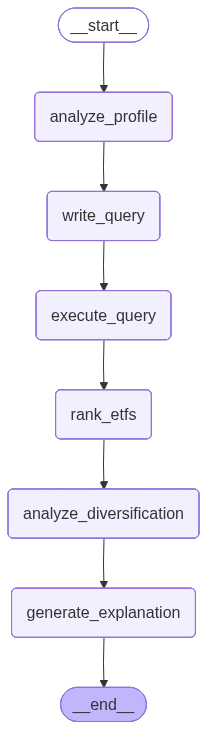

In [69]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 상태 그래프 생성
graph_builder = StateGraph(State)

graph_builder.add_node("analyze_profile", analyze_profile)
graph_builder.add_node("write_query", write_query)
graph_builder.add_node("execute_query", execute_query)
graph_builder.add_node("rank_etfs", rank_etfs)
graph_builder.add_node("analyze_diversification", analyze_diversification)
graph_builder.add_node("generate_explanation", generate_explanation)



graph_builder.add_edge(START, "analyze_profile")
graph_builder.add_edge("analyze_profile", "write_query")
graph_builder.add_edge("write_query", "execute_query")
graph_builder.add_edge("execute_query", "rank_etfs")
#graph_builder.add_edge("rank_etfs", "generate_explanation")
graph_builder.add_edge("rank_etfs", "analyze_diversification")
graph_builder.add_edge("analyze_diversification", "generate_explanation")
graph_builder.add_edge("generate_explanation", END)

graph = graph_builder.compile()


# 상태 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [70]:
# 사용자 질문 예시

test_questions = [
    """
    40대 중반의 직장인입니다. 
    월 200만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    저위험 안정적인 수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """,
    """
    20대 후반의 대학생입니다. 
    월 50만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    고위험 고수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """,
    """
    32살 맞벌이 부부입니다. 
    둘이 합쳐서 월 200만원을 노후자금으로 굴리고 싶어요. 
    제약/바이오와 클라우드 컴퓨팅 쪽을 보고 있습니다. 
    안정성과 수익성의 균형을 맞추고 싶고, 
    지속가능한 기업들 위주로 투자하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """
]


# 상태 그래프 실행
etf_recommendations = []
for question in test_questions:
    etf_recommendation = graph.invoke(
        {"question": question}
    )
    etf_recommendations.append(etf_recommendation)

========== [실행할 SQL 쿼리] ==========
SELECT 종목명, 종목코드, 분류체계, 기초지수, 운용사, 수익률_최근1년, 순자산총액, 총보수, 변동성
FROM ETFs
WHERE (
    분류체계 LIKE '%금리%' OR
    기초지수 LIKE '%금리%' OR
    분류체계 LIKE '%ESG%' OR
    기초지수 LIKE '%ESG%' OR
    분류체계 LIKE '%환율%' OR
    기초지수 LIKE '%환율%'
)
AND 총보수 <= 0.005
AND 순자산총액 >= 10000000000
ORDER BY 변동성 ASC, 수익률_최근1년 DESC, 총보수 ASC
LIMIT 10;


ValidationError: 1 validation error for ETFRankingResult
rankings
  Value error, 최소 1개 이상의 ETF 랭킹이 생성되어야 합니다. [type=value_error, input_value=[], input_type=list]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

In [ ]:
# 결과 출력
Markdown(etf_recommendations[0]["final_answer"]["markdown"])